# Практическая работа 16 (Тест)

## Настройка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import minkowski

## Вопрос 1

Выполните предобработку данных:

- переименуйте столбцы Annual Income (k$) в Income и Spending Score (1-100) в Score;
- прямое кодирование категориального столбца Genre с помощью функции pd.get_dummies();
- стандартизация данных.

Результат сохраните в датафрейм `X_scaled_df`:

In [2]:
df = pd.read_csv('Mall_Customers.csv', index_col='CustomerID')
df.index = df.index.astype(int)
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [3]:
# Переименование столбцов
df = df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'
})

# Прямое кодирование категориального столбца Genre
df_encoded = pd.get_dummies(df, columns=['Genre'])

# Подготовка данных для стандартизации (CustomerID уже является индексом)
X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Сохранение результата в датафрейм X_scaled_df с CustomerID как числовым индексом
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=df.index)
X_scaled_df.head()

,Age,Income,Score,Genre_Female,Genre_Male
CustomerID,,,,,
1,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
2,-1.281035,-1.738999,1.195704,-1.128152,1.128152
3,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
4,-1.137502,-1.700830,1.040418,0.886405,-0.886405
5,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


В качестве ответа укажите стандартизированное значение уровня расходов клиента с CustomerID = 5, округлённое до 3 знаков после запятой.

In [4]:
round(X_scaled_df.loc[5]['Income'], 3)

np.float64(-1.663)

## Вопрос 2

Укажите расстояние между клиентами с `CustomerID` 2 и 3, измеренное с использованием метрики Минковского с `p=3`. Ответ округлите до 2 знаков после запятой.


In [5]:
round(minkowski(X_scaled_df.loc[2], X_scaled_df.loc[3], p=3), 2)

np.float64(3.45)

## Вопрос 3

Выполним построение модели k-средних и осуществим подбор оптимального количества кластеров с помощью метрики `WCSS`. Для этого обучим модель с разным количеством кластеров, например, от 2 до 10 и с помощью свойства `inertia_` обученной модели получим значение метрики для каждого случая. В качестве ответа укажите значение метрики для 9 кластеров, округлённое до 2 знаков после запятой.

In [6]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10).fit(X_scaled_df)
    wcss.append(kmeans.inertia_)
round(wcss[7], 2) # Индекс 7 соответствует 9 кластерам (2..10)

174.15

## Вопрос 4

Визуализируйте зависимость метрики `WCSS` от кол-ва кластеров на основе результатов прошлого задания. С помощью метода локтя найдите "излом" на этой кривой - точку, после которой метрика продолжает падать уже значительно медленнее. В нашем случае будем считать точкой "излома" уменьшение ошибки менее чем на 100. В качестве ответа укажите оптимальное кол-во кластеров для построения модели k-средних, подобранное с помощью метода локтя.

In [7]:
# Логика: находим первую разницу < 100
diffs = [wcss[i] - wcss[i+1] for i in range(len(wcss)-1)]
optimal_k = next(i + 2 for i, diff in enumerate(diffs) if diff < 100)
optimal_k

4

## Вопрос 5

Выполним построение модели k-средних для подобранного значения кол-ва кластеров:

```py
k_means = KMeans(n_clusters=..., random_state=42).fit(X_scaled_df)
```

В качестве ответа укажите координату центра кластера с меткой 2 по оси признака `Income`, округлённую до 2 знаков после запятой.

In [8]:
k_means = KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit(X_scaled_df)
round(k_means.cluster_centers_[2, X_scaled_df.columns.get_loc('Income')], 2)

np.float64(-0.09)

## Вопрос 6

Укажите, к какому кластеру принадлежит объект с `CustomerID` = 5.

In [9]:
k_means.labels_[4]

np.int32(2)

## Вопрос 7

Была выполнена визуализация зависимости двух признаков друг от друга с наложенными центрами кластеров:

На оси x находятся значения признака \_\_\_, на оси y - \_\_\_.

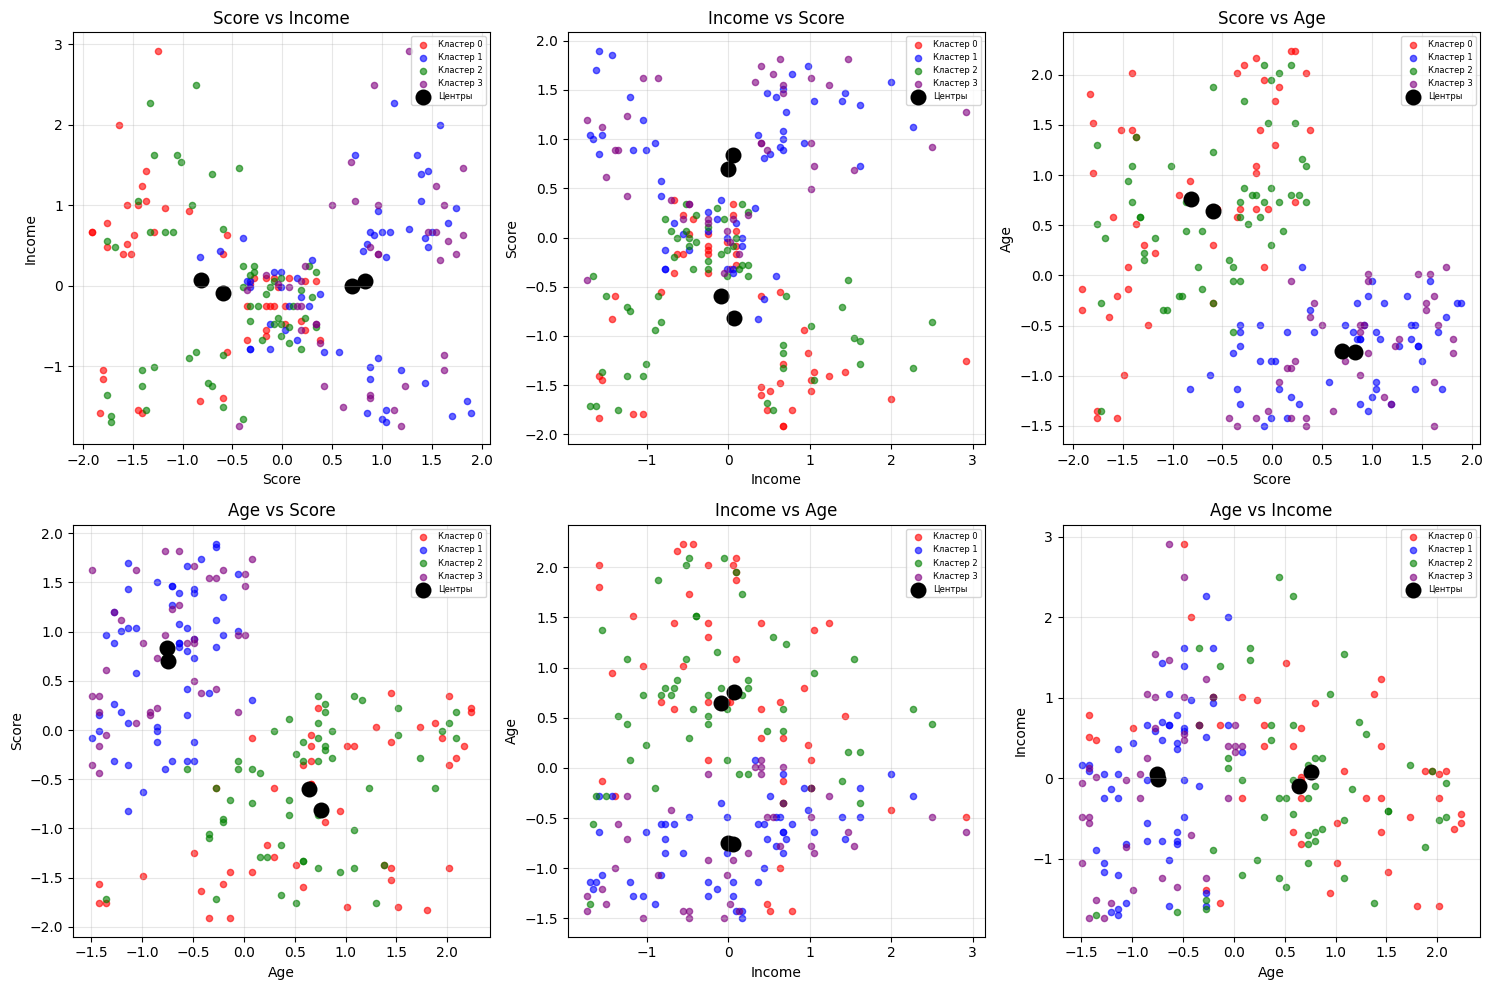

In [10]:
# Определяем индексы признаков для визуализации
age_index = list(X_scaled_df.columns).index('Age')
income_index = list(X_scaled_df.columns).index('Income')
score_index = list(X_scaled_df.columns).index('Score')

# Получаем предсказания кластеров для всех объектов
clusters = k_means.predict(X_scaled_df)
centers = k_means.cluster_centers_

# Создаем subplot со всеми возможными комбинациями
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Комбинации признаков для визуализации
combinations = [
    (score_index, income_index, 'Score', 'Income'),
    (income_index, score_index, 'Income', 'Score'),
    (score_index, age_index, 'Score', 'Age'),
    (age_index, score_index, 'Age', 'Score'),
    (income_index, age_index, 'Income', 'Age'),
    (age_index, income_index, 'Age', 'Income')
]

# Создаем графики для каждой комбинации
for idx, (x_idx, y_idx, x_label, y_label) in enumerate(combinations):
    ax = axes[idx // 3, idx % 3]
    
    # Визуализация точек по кластерам
    for i in range(optimal_k):
        cluster_points = X_scaled_df[clusters == i]
        ax.scatter(cluster_points.iloc[:, x_idx], 
                   cluster_points.iloc[:, y_idx], 
                   c=colors[i % len(colors)], 
                   label=f'Кластер {i}', 
                   alpha=0.6, 
                   s=20)
    
    # Визуализация центров кластеров
    ax.scatter(centers[:, x_idx], 
               centers[:, y_idx], 
               c='black', 
               marker='o', 
               s=100, 
               edgecolors='black', 
               linewidths=1.5, 
               label='Центры')
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{x_label} vs {y_label}')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Определяем названия признаков на осях (по умолчанию Score и Income)
x_axis_feature = 'Score'
y_axis_feature = 'Income'

## Вопрос 8

С использованием построенной модели выполните предсказание для нового объекта, предварительно выполнив стандартизацию признаков с помощью обученного объекта `scaler`:

```py
customer = pd.Series({'Age': 20, 'Income': 100, 'Score': 80, 'Genre_Female':0, 'Genre_Male':1})
```

В качестве ответа выберите кластер, к которому его отнесёт модель.

In [11]:
# 1. Создаем объект (важно, чтобы порядок столбцов соответствовал X_scaled_df)
customer = pd.DataFrame([{'Age': 20, 'Income': 100, 'Score': 80, 'Genre_Female': 0, 'Genre_Male': 1}])

# 2. Приводим порядок столбцов в соответствие с обученным DataFrame
customer = customer[X_scaled_df.columns]

# 3. Стандартизируем признаки с помощью уже обученного объекта scaler
customer_scaled = scaler.transform(customer)

# 4. Предсказываем кластер
predicted_cluster = k_means.predict(customer_scaled)

predicted_cluster[0]

/Users/efim/dev/university-6sem-data-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


np.int32(3)

## Вопрос 9

Для того, чтобы продемонстрировать, насколько адекватно работает алгоритм k-средних, обучим его на плоском наборе данных, состоящим всего из двух признаков: `Income` и `Score`. Для этого выполним извлечение стандартизированных значений данных признаков и сохраним в переменную `X_flat_df`.

Подберите оптимальное кол-во кластеров с помощью метода локтя, предварительно вычислив значения метрики `WCSS` для кол-ва кластеров от 2 до 10. В качестве ответа укажите значение метрики `WCSS` для 4 кластеров, округлённое до 2 знаков после запятой.

In [12]:
# 1. Извлекаем признаки Income и Score из стандартизированных данных
X_flat_df = X_scaled_df[['Income', 'Score']]

# 2. Вычисляем WCSS для количества кластеров от 2 до 10
wcss_flat = []
for i in range(2, 11):
    kmeans_flat = KMeans(n_clusters=i, random_state=42, n_init=10).fit(X_flat_df)
    wcss_flat.append(kmeans_flat.inertia_)

# 3. Значение для 4 кластеров
# Индексы: 2 кластера -> индекс 0, 3 кластера -> индекс 1, 4 кластера -> индекс 2
round(wcss_flat[2], 2)

108.92

## Вопрос 10

Для подбора оптимального кол-ва кластеров есть ещё один подход - метод Силуэта. Вычисление метрики реализовано в библиотеке `sklearn` с помощью функции `silhouette_score`. Рассчитайте значения коэффициента Силуэта для кол-ва кластеров от 2 до 10 и найдите, при каком значении кол-ва кластеров наблюдается максимальное значение коэффициента. Совпали ли результаты выбора оптимального кол-ва кластеров двух методов?

В качестве ответа укажите значение коэффициента Силуэта для 7 кластеров, округлённое до 2 знаков после запятой.

In [13]:
# Список для хранения коэффициентов силуэта
silhouette_scores = []

# Перебираем количество кластеров от 2 до 10
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10).fit(X_flat_df)
    score = silhouette_score(X_flat_df, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Кластеров: {i}, Силуэт: {round(score, 2)}")

# Находим максимальное значение коэффициента Силуэта и соответствующее количество кластеров
max_silhouette = max(silhouette_scores)
optimal_k_silhouette = silhouette_scores.index(max_silhouette) + 2  # +2 потому что начинаем с k=2

# Ответ на вопрос про 7 кластеров (индекс 5, так как начинали с 2)
round(silhouette_scores[5], 2)

Кластеров: 2, Силуэт: 0.32
Кластеров: 3, Силуэт: 0.47
Кластеров: 4, Силуэт: 0.49
Кластеров: 5, Силуэт: 0.55
Кластеров: 6, Силуэт: 0.54
Кластеров: 7, Силуэт: 0.53
Кластеров: 8, Силуэт: 0.46
Кластеров: 9, Силуэт: 0.46
Кластеров: 10, Силуэт: 0.44


0.53

## Вопрос 11

Выполним построение модели k-средних с двумя признаками для подобранного значения кол-ва кластеров:

```py
k_means = KMeans(n_clusters=..., random_state=42).fit(X_flat_df)
```

В качестве ответа укажите через пробел координаты центра кластера с меткой 3, округлённые до 2 знаков после запятой. Формат ввода: `0.00 0.00`

In [14]:
# Построение модели k-средних с оптимальным количеством кластеров (по методу Силуэта)
k_means_flat = KMeans(n_clusters=optimal_k_silhouette, random_state=42).fit(X_flat_df)

# Получение координат центра кластера с меткой 3
# Округляем координаты до 2 знаков после запятой
print(k_means_flat.cluster_centers_[3].round(2))

[ 1.06 -1.28]


## Вопрос 12

Укажите кол-во объектов в кластере с меткой 2.

In [15]:
# Получаем предсказания кластеров для всех объектов
clusters_flat = k_means_flat.predict(X_flat_df)

# Подсчитываем количество объектов в кластере с меткой 2
(clusters_flat == 2).sum()

np.int64(22)

## Вопрос 13

Выполним визуализацию зависимости уровня расходов от годового дохода с наложенными центрами кластеров:

Теперь мы получаем довольно ожидаемую картину, когда алгоритм объединил в кластеры сгущения точек, хорошо просматриваемые на диаграмме. Предположим, что у нас есть стандартизированные данные нового человека с годовым доходом = 0.9 и уровнем расходов -1.6. С использованием диаграммы визуально оцените, к какому кластеру модель его отнесёт.

/Users/efim/dev/university-6sem-data-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


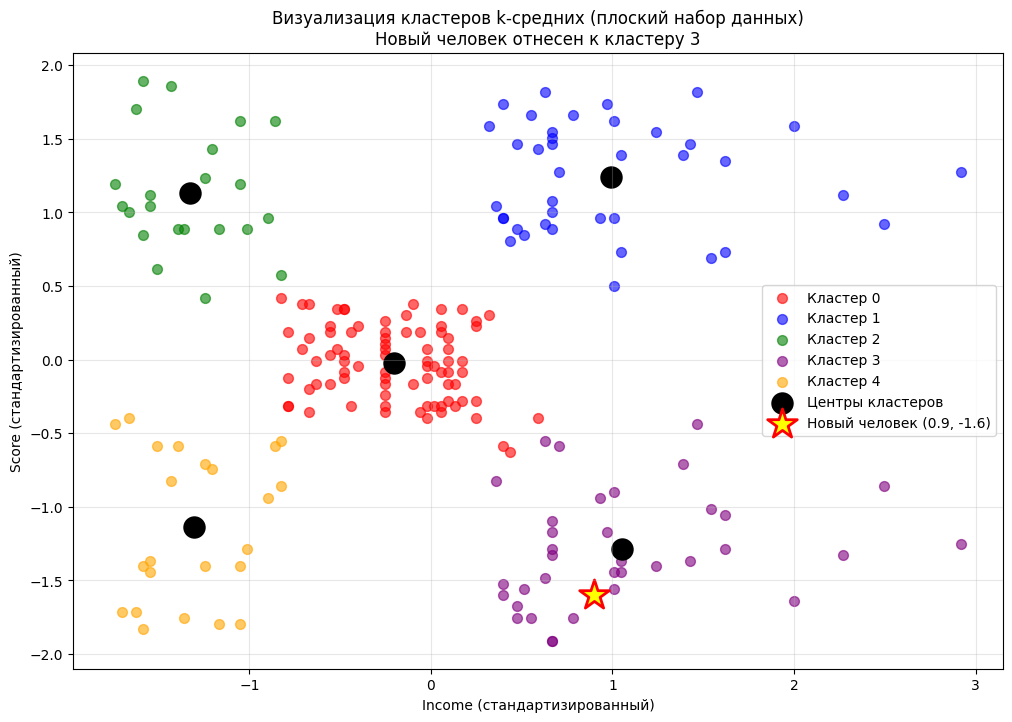

Модель отнесла нового человека к кластеру: 3


In [16]:
# Создаем визуализацию
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Визуализация точек по кластерам
# X_flat_df содержит Income (столбец 0) и Score (столбец 1)
for i in range(optimal_k_silhouette):
    cluster_points = X_flat_df[clusters_flat == i]
    plt.scatter(cluster_points.iloc[:, 0],  # Income
                cluster_points.iloc[:, 1],  # Score
                c=colors[i % len(colors)], 
                label=f'Кластер {i}', 
                alpha=0.6, 
                s=50)

# Визуализация центров кластеров
centers_flat = k_means_flat.cluster_centers_
plt.scatter(centers_flat[:, 0],  # Income
            centers_flat[:, 1],  # Score
            c='black', 
            marker='o', 
            s=200, 
            edgecolors='black', 
            linewidths=2, 
            label='Центры кластеров')

# Добавляем точку нового человека
new_person_income = 0.9
new_person_score = -1.6
plt.scatter(new_person_income, 
            new_person_score, 
            c='yellow', 
            marker='*', 
            s=500, 
            edgecolors='red', 
            linewidths=2, 
            label='Новый человек (0.9, -1.6)')

# Выполняем предсказание для нового человека
new_person_data = np.array([[new_person_income, new_person_score]])
predicted_cluster_new = k_means_flat.predict(new_person_data)[0]

plt.xlabel('Income (стандартизированный)')
plt.ylabel('Score (стандартизированный)')
plt.title(f'Визуализация кластеров k-средних (плоский набор данных)\nНовый человек отнесен к кластеру {predicted_cluster_new}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Модель отнесла нового человека к кластеру: {predicted_cluster_new}")

Перейдём к построению модели агломеративной иерархической кластеризации.

**Справка:** при создании модели `AgglomerativeClustering` ей передается два аргумента: `distance_threshold` и `n_clusters`, причем они работают альтернативно. Мы можем задать определенное количество кластеров, тогда порог рассечения игнорируется (задается как `None`), или наоборот задать порог функции расстояния, тогда количество кластеров алгоритм будет выбирать сам и нам нужно задать в этом параметре значение `None`.

На рисунке ниже представлена дендрограмма алгоритма агломеративной иерархической кластеризации для нашего набора данных:

По вертикали на ней отложено расстояние между объектами или кластерами. По горизонтали - объекты набора данных. Соответственно, на уровне самих объектов расстояние между ними равно нулю (расстояние от объекта до самого себя). Ближайшие объекты объединяются в группу, что отражается на дендрограмме характерной формой с перемычкой на том вертикальном уровне, который соответствует расстоянию между объектами. Затем эти группы объединяются между собой, и так до тех пор, пока вся выборка не будет объединена. Чем две точки выборки дальше друг от друга, тем позже они попадут в один кластер, и тем выше на дендрограмме будет это объединение.

Выделить определённое число кластеров мы можем с помощью рассечения горизонтальной линией на определенной высоте. Тогда точки, которые попали в одну группу будут "зачислены" в общий кластер. Чем ниже мы обрезаем дендрограмму, тем мельче будут кластеры, но больше их количество. Именно за этот уровень и отвечает аргумент `distance_threshold` конструктора класса агломеративной кластеризации.


## Вопрос 14

Предположим, что мы выберем в качестве порога рассечения значение = 13. Оцените по дендрограмме, какое кол-во кластеров будет выделено.

In [17]:
# Построение модели агломеративной кластеризации с порогом рассечения = 13
# Используем плоский набор данных X_flat_df (Income и Score)
agg_clustering = AgglomerativeClustering(distance_threshold=13, n_clusters=None, linkage='ward')
cluster_labels_agg = agg_clustering.fit_predict(X_flat_df)

# Определяем количество кластеров
print(agg_clustering.n_clusters_)

3


## Вопрос 15

Выполните построение модели агломеративной иерархической кластеризации с параметром `distance_threshold=10` на стандартизированном наборе данных со всеми признаками `X_scaled_df`. В качестве ответа укажите кол-во объектов в кластере с меткой 3.

In [18]:
# Построение модели агломеративной кластеризации с порогом рассечения = 10
# Используем полный стандартизированный набор данных X_scaled_df со всеми признаками
agg_clustering_full = AgglomerativeClustering(distance_threshold=10, n_clusters=None, linkage='ward')
cluster_labels_agg_full = agg_clustering_full.fit_predict(X_scaled_df)

# Подсчитываем количество объектов в кластере с меткой 3
(cluster_labels_agg_full == 3).sum()

np.int64(53)

## Вопрос 16

Выберите выводы, которые можно сделать на основании проведённого анализа.

1. [✓] Оптимальное кол-во кластеров в алгоритме k-средних можно определить с помощью метода локтя или метода силуэта.
2. [✓] Алгоритм агломеративной кластеризации не может вычислить прогнозы для новых точек данных.
3. [✗] Алгоритм кластеризации k-средних в процессе своей работы автоматически рассчитывает оптимальное кол-во кластеров.
4. [✗] При создании модели агломеративной кластеризации обязательно нужно задать значения 2 параметров: кол-во кластеров и порог функции расстояния. Если какой-то из этих параметров не задан (None), алгоритм не будет работать.

Анализ выводов на основе проведённого анализа:

1. [✓] Верно - мы использовали оба метода (локтя и силуэта) для подбора оптимального количества кластеров
2. [✓] Верно - AgglomerativeClustering не имеет метода predict() для новых данных
3. [✗] Неверно - k-средних требует указания количества кластеров заранее, мы сами подбирали оптимальное значение
4. [✗] Неверно - параметры distance_threshold и n_clusters работают альтернативно, можно задать только один